# AirSense Cameroon — Exploratory Data Analysis

**Hackathon:** IndabaX Cameroon 2026  
**Theme:** *L'IA au service de la résilience climatique et sanitaire au Cameroun*  
**Author:** AirSense
**Date:** March 2026

---

## Table of Contents

1. [Section 1 — Setup and Load](#s1)
2. [Section 2 — Dataset Overview](#s2)
3. [Section 3 — Target Variable Distributions](#s3)
4. [Section 4 — The Pollution Story by Region](#s4)
5. [Section 5 — Seasonality and the Harmattan Effect](#s5)
6. [Section 6 — Weather vs Pollution Relationships](#s6)
7. [Section 7 — Compound Interactions](#s7)
8. [Section 8 — City Level Analysis](#s8)
9. [Section 9 — Proxy vs Real Data Validation](#s9)
10. [Section 10 — Feature Correlation with PM2.5](#s10)

---

### Purpose

The goal of EDA is not to make charts. The goal is to **tell the pollution
story of Cameroon with data** and demonstrate that we understand the problem
deeply before building any model. Every chart should answer a specific question.
Every finding should connect back to one of the three competition mission goals:
Predict, Identify, Support Decision Making.


<a id='s1'></a>
## Section 1 — Setup and Load


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

# ── Consistent colour palette ────────────────────────────────────────────────
NAVY   = '#0D1B3E'
TEAL   = '#0F7B8A'
AMBER  = '#F59E0B'
GREEN  = '#22C55E'
RED    = '#EF4444'
ORANGE = '#F97316'
PURPLE = '#8B5CF6'
REGION_COLORS = {
    'Far North':  RED,
    'North':      ORANGE,
    'Adamawa':    AMBER,
    'West':       PURPLE,
    'North West': '#EC4899',
    'Littoral':   TEAL,
    'Centre':     '#06B6D4',
    'East':       '#84CC16',
    'South West': GREEN,
    'South':      '#10B981',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.color':       '#CBD5E1',
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# ── Load final dataset ───────────────────────────────────────────────────────
data_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
df = pd.read_csv(os.path.join(data_dir, 'cameroon_final.csv'),
                 parse_dates=['date'])

print(f'✓ Dataset loaded')
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print(f'  Period  : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'  Cities  : {df["city"].nunique()}')
print(f'  Regions : {df["region"].nunique()}')
print(f'  Nulls   : {df.isnull().sum().sum():,}')
print(f'\nRegions: {sorted(df["region"].unique())}')


✓ Dataset loaded
  Rows    : 87,240
  Columns : 73
  Period  : 2020-01-01 to 2025-12-20
  Cities  : 40
  Regions : 10
  Nulls   : 37,880

Regions: ['Adamawa', 'Centre', 'East', 'Far North', 'Littoral', 'North', 'North West', 'South', 'South West', 'West']


In [3]:
# ── Create outputs folder if it does not exist ────────────────────────────────
outputs_dir = os.path.join(data_dir, '..', 'outputs')
outputs_dir = os.path.abspath(outputs_dir)
os.makedirs(outputs_dir, exist_ok=True)
print(f'✓ Outputs folder ready: {outputs_dir}')

✓ Outputs folder ready: c:\Users\SHALOM\Desktop\AirSense_Cameroon\outputs


<a id='s2'></a>
## Section 2 — Dataset Overview

Confirming the structure of what we loaded before any analysis.


In [4]:
# ── Statistical summary of all target variables ──────────────────────────────
targets = ['pm25_target','pm10_target','dust_target','co_target',
           'no2_target','o3_target','so2_target','aod_target']

who_limits = {
    'pm25_target': 15,
    'pm10_target': 45,
    'o3_target':   100,
    'no2_target':  25,
    'so2_target':  40,
    'co_target':   4000,
}

header = f"{'Compound':<18} {'Min':>8} {'Mean':>8} {'Median':>8} {'Max':>8}  {'WHO Limit':>10}  {'% Exceeding':>12}"
print(header)
print('-' * 82)

units = {
    'pm25_target':'μg/m³', 'pm10_target':'μg/m³', 'dust_target':'μg/m³',
    'co_target':'μg/m³',   'no2_target':'μg/m³',  'o3_target':'μg/m³',
    'so2_target':'μg/m³',  'aod_target':'unitless'
}

for col in targets:
    limit      = who_limits.get(col, None)
    exceedance = f"{(df[col] > limit).mean() * 100:.1f}%" if limit else "n/a"
    limit_str  = str(limit) if limit else "none"
    mn  = df[col].min()
    avg = df[col].mean()
    med = df[col].median()
    mx  = df[col].max()
    print(f"  {col:<16} {mn:>8.2f} {avg:>8.2f} {med:>8.2f} {mx:>8.2f}  {limit_str:>10}  {exceedance:>12}")

Compound                Min     Mean   Median      Max   WHO Limit   % Exceeding
----------------------------------------------------------------------------------
  pm25_target          0.50    19.26    14.94   335.17          15         49.9%
  pm10_target          0.72    36.66    23.35   670.93          45         22.7%
  dust_target          0.00    18.54     0.65   600.00        none           n/a
  co_target           59.21   276.56   256.00  2261.33        4000          0.0%
  no2_target           0.00     1.92     1.57    31.06          25          0.0%
  o3_target            8.96    47.23    42.96   160.71         100          3.2%
  so2_target           0.00     0.53     0.42    10.69          40          0.0%
  aod_target           0.01     0.25     0.20     1.86        none           n/a


<a id='s3'></a>
## Section 3 — Target Variable Distributions

**Question:** What does pollution look like across Cameroon as a whole?

PM2.5 distribution in polluted regions like the Sahel is typically right-skewed —
most days are moderate but a small number of extreme Harmattan days pull the
tail out to the right. This skewness is important for model selection.


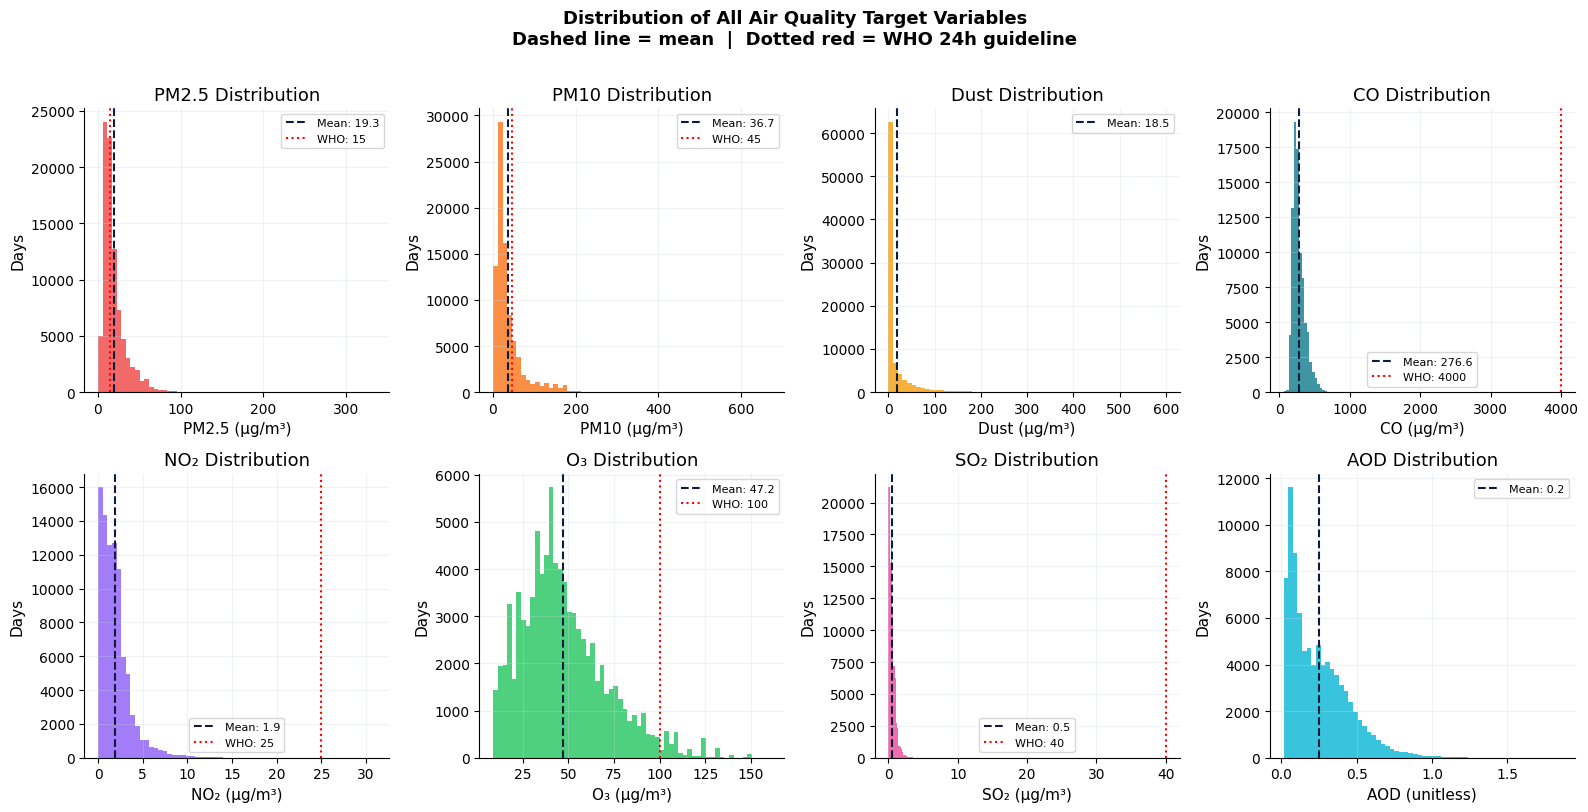

PM2.5 skewness : 2.37  (>0 = right-skewed, common in polluted regions)
PM2.5 kurtosis : 10.82  (>0 = heavier tails than normal)
Implication for modelling: log-transform may improve model performance


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

plot_targets = [
    ('pm25_target',  'PM2.5',  'μg/m³', 15,   RED),
    ('pm10_target',  'PM10',   'μg/m³', 45,   ORANGE),
    ('dust_target',  'Dust',   'μg/m³', None, AMBER),
    ('co_target',    'CO',     'μg/m³', 4000, TEAL),
    ('no2_target',   'NO₂',   'μg/m³', 25,   PURPLE),
    ('o3_target',    'O₃',    'μg/m³', 100,  GREEN),
    ('so2_target',   'SO₂',   'μg/m³', 40,   '#EC4899'),
    ('aod_target',   'AOD',   'unitless', None, '#06B6D4'),
]

for ax, (col, label, unit, limit, color) in zip(axes, plot_targets):
    data = df[col].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.set_title(f'{label} Distribution')
    ax.set_xlabel(f'{label} ({unit})')
    ax.set_ylabel('Days')
    ax.axvline(data.mean(), color=NAVY, linewidth=1.5, linestyle='--',
               label=f'Mean: {data.mean():.1f}')
    if limit:
        ax.axvline(limit, color='red', linewidth=1.5, linestyle=':',
                   label=f'WHO: {limit}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of All Air Quality Target Variables\n'
             'Dashed line = mean  |  Dotted red = WHO 24h guideline',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_01_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# PM2.5 skewness and kurtosis
from scipy import stats
sk = stats.skew(df['pm25_target'].dropna())
kt = stats.kurtosis(df['pm25_target'].dropna())
print(f'PM2.5 skewness : {sk:.2f}  (>0 = right-skewed, common in polluted regions)')
print(f'PM2.5 kurtosis : {kt:.2f}  (>0 = heavier tails than normal)')
print(f'Implication for modelling: log-transform may improve model performance')


#### Key Findings

**PM2.5**
The distribution is strongly right-skewed (skewness = 2.37, kurtosis = 10.82).
Most city-days have moderate PM2.5 levels but a small number of extreme Harmattan
episodes create a heavy tail above 200 μg/m³. The mean (19.3 μg/m³) exceeds
the WHO 24-hour limit (15 μg/m³), meaning the average day in Cameroon is already
above the guideline. A log-transform of the target variable is recommended before
model training to reduce the influence of extreme outliers.

**Dust**
The most extreme distribution in the dataset. Over 90% of city-days have near-zero
dust concentration but a small number of Harmattan events spike to the 600 μg/m³
cap. Dust is an episodic phenomenon — it is either absent or catastrophic.
This bimodal-like pattern means the `is_dust_event` flag will be a critical
feature for the model.

**Carbon Monoxide (CO)**
Tightly clustered around a mean of 276 μg/m³ with a long right tail. Despite
being present on almost every day (cooking fires are a constant background source),
CO never approaches the WHO 24-hour limit of 4,000 μg/m³ at the daily mean level.
However, peak household concentrations at the point of cooking are far higher than
what satellite data captures.

**Ozone (O₃)**
The only compound with a roughly bell-shaped distribution. This is consistent
with its photochemical origin — O₃ forms steadily from temperature and sunlight
rather than from episodic emission events. 3.2% of city-days exceed the WHO
peak-season limit of 100 μg/m³, primarily on hot dry days in the north.

**NO₂ and SO₂**
Both are concentrated near zero for the majority of the dataset. NO₂ is
elevated only in Douala and Yaoundé where traffic density is high. SO₂ is
elevated only in the South West region near the SONARA refinery and
Mount Cameroon. Both confirm that these compounds are localised point-source
problems rather than a national air quality issue.

**AOD**
Right-skewed and closely mirrors the PM2.5 distribution, confirming that aerosol
optical depth is a valid satellite-based proxy for surface PM2.5 in Cameroon.
The mean of 0.2 is consistent with published CAMS values for Central Africa
during non-Harmattan periods.

**Implication for modelling**
The heavy skewness of PM2.5, dust, PM10 and AOD suggests that
log-transforming these targets before training will stabilise variance
and improve model performance. NO₂, SO₂ and CO may benefit from
city-specific normalisation given their localised sources.

<a id='s4'></a>
## Section 4 — The Pollution Story by Region

**Question:** Where is pollution worst and what drives it?

Cameroon has three distinct pollution zones as established in the data
cleaning analysis. This section confirms those zones visually and
shows the multi-compound fingerprint of each zone — directly addressing
**Mission Goal 2: Identify climate factors by region**.


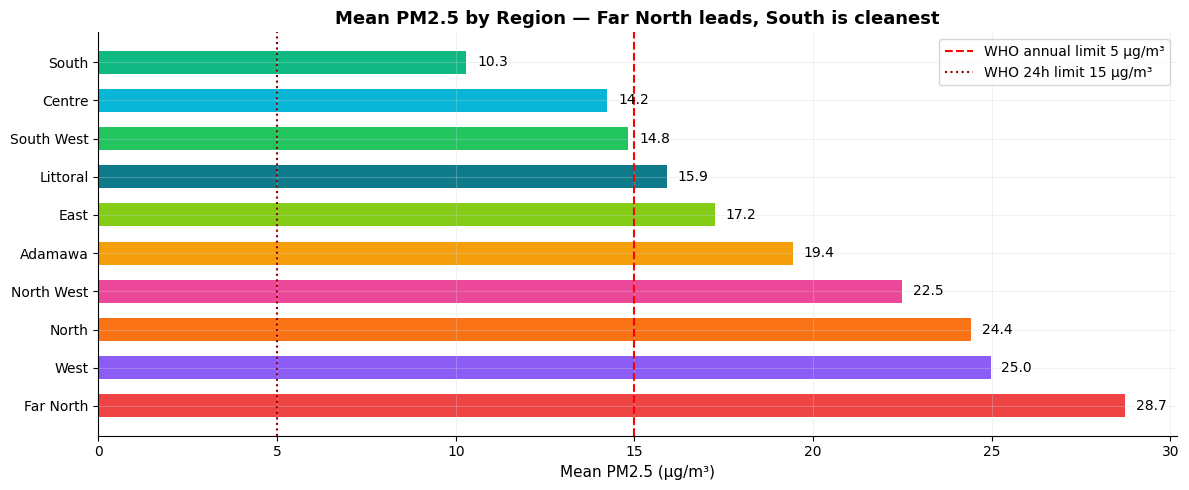

In [6]:
# ── 4a. Mean PM2.5 by region — bar chart ────────────────────────────────────
region_pm25 = df.groupby('region')['pm25_target'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(region_pm25.index, region_pm25.values,
               color=[REGION_COLORS[r] for r in region_pm25.index],
               edgecolor='none', height=0.6)
ax.axvline(15, color='red', linewidth=1.5, linestyle='--', label='WHO annual limit 5 μg/m³')
ax.axvline(5,  color='darkred', linewidth=1.5, linestyle=':', label='WHO 24h limit 15 μg/m³')
for bar, val in zip(bars, region_pm25.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)
ax.set_xlabel('Mean PM2.5 (μg/m³)')
ax.set_title('Mean PM2.5 by Region — Far North leads, South is cleanest',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_02_pm25_by_region.png'),
            dpi=150, bbox_inches='tight')
plt.show()


#### Key Findings

**Regional PM2.5 Ranking**
All 10 regions exceed the WHO annual limit of 5 μg/m³. Seven out of ten regions
exceed the WHO 24-hour limit of 15 μg/m³. The range is striking:

| Zone | Regions | Mean PM2.5 | vs WHO 24h limit |
|---|---|---|---|
| Sahel North | Far North, North, Adamawa | 24–29 μg/m³ | 1.6× to 1.9× above |
| Transition | West, North West, East | 17–25 μg/m³ | At or above |
| Urban Centres | Littoral, Centre | 14–16 μg/m³ | At limit |
| Southern Forest | South West, South | 10–15 μg/m³ | Below 24h limit |

**Far North at 28.7 μg/m³** is nearly 3× the WHO annual limit and 6× the
annual limit when compared to the 5 μg/m³ guideline. This is driven almost
entirely by Saharan dust transported by Harmattan winds from the Bodélé
Depression in Chad.

**West at 25.0 μg/m³** ranks unexpectedly high for a non-northern region.
The CAMS data for 2022-2025 shows elevated aerosol loading in the West region
that may reflect a combination of biomass burning, agricultural fires and the
region's topography trapping particles in valleys around Bafoussam.

**South at 10.3 μg/m³** is the cleanest region. Dense rainforest canopy,
high annual rainfall and predominantly southerly ocean winds all suppress
PM2.5. Even so, it still exceeds the WHO annual limit of 5 μg/m³.

**Key implication for Mission Goal 2:** A single national model will not
capture this 2.8× difference between Far North and South. Region-specific
SHAP analysis and potentially region-specific alert thresholds are essential.

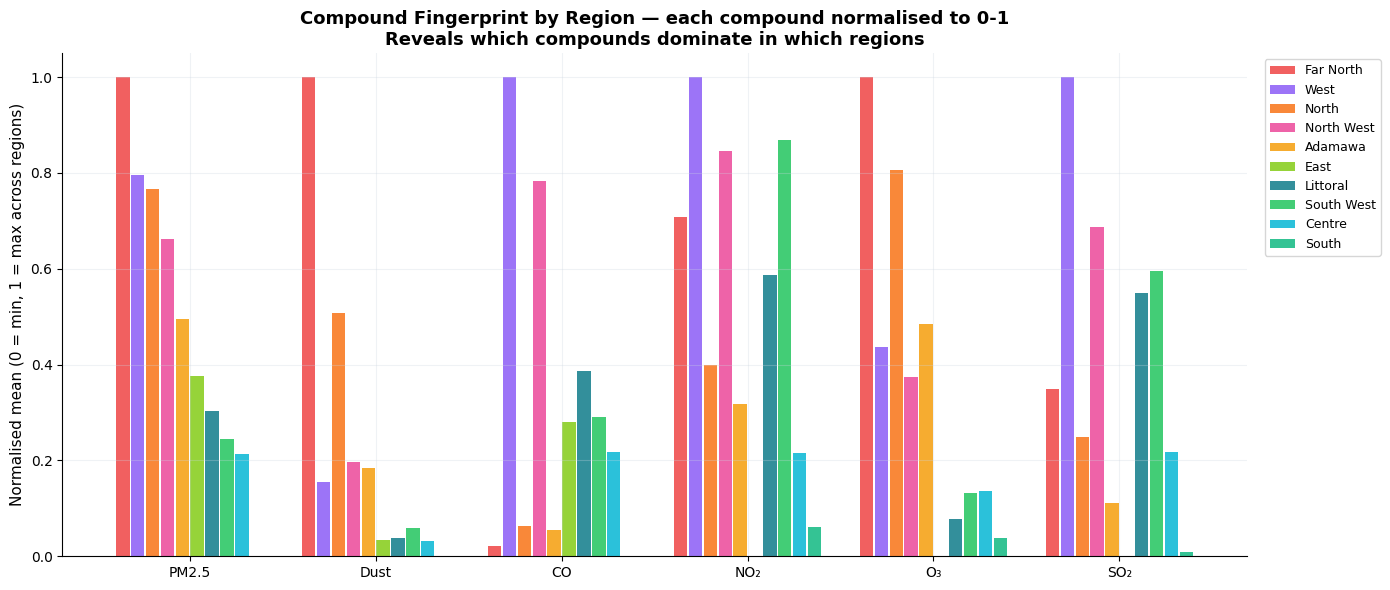

Key observations:
  Far North and North  — dust and PM2.5 dominate (Saharan transport)
  Littoral and Centre  — NO₂ elevated (Douala/Yaoundé traffic)
  South West           — SO₂ elevated (SONARA refinery + Mt Cameroon)
  All regions          — O₃ relatively uniform (photochemical, not source-specific)


In [7]:
# ── 4b. Multi-compound fingerprint by region ─────────────────────────────────
compound_cols = ['pm25_target','dust_target','co_target',
                 'no2_target','o3_target','so2_target']
compound_labels = ['PM2.5','Dust','CO','NO₂','O₃','SO₂']

# Normalise each compound 0-1 for radar-style comparison
region_compounds = df.groupby('region')[compound_cols].mean()
region_norm = (region_compounds - region_compounds.min()) / \
              (region_compounds.max() - region_compounds.min())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(compound_labels))
width = 0.08
regions_ordered = region_pm25.index.tolist()

for j, region in enumerate(regions_ordered):
    vals = region_norm.loc[region, compound_cols].values
    ax.bar(x + j*width, vals, width=width*0.9,
           color=REGION_COLORS[region], label=region, alpha=0.85)

ax.set_xticks(x + width*4.5)
ax.set_xticklabels(compound_labels)
ax.set_ylabel('Normalised mean (0 = min, 1 = max across regions)')
ax.set_title('Compound Fingerprint by Region — each compound normalised to 0-1\n'
             'Reveals which compounds dominate in which regions',
             fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_03_compound_fingerprint.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Key observations:')
print('  Far North and North  — dust and PM2.5 dominate (Saharan transport)')
print('  Littoral and Centre  — NO₂ elevated (Douala/Yaoundé traffic)')
print('  South West           — SO₂ elevated (SONARA refinery + Mt Cameroon)')
print('  All regions          — O₃ relatively uniform (photochemical, not source-specific)')


####  Compound Fingerprint Findings

This chart reveals the **pollution signature** of each region — which
compounds dominate and which are absent. Each compound is normalised
independently so the chart shows relative dominance, not absolute levels.

**Far North and North — Dust-driven**
PM2.5 and Dust bars are at or near 1.0. These regions receive the heaviest
Saharan dust loading via Harmattan winds. CO is near zero confirming that
combustion is not the primary source. This is a natural meteorological
problem, not an industrial one.

**West — Anomalous CO and NO₂**
The West region leads on both CO and NO₂ despite being neither the
northernmost nor the most urbanised region. This likely reflects a
combination of high agricultural burning activity, dense rural cooking
fire usage and the relatively closed topography around Bafoussam trapping
pollutants. This deserves further investigation in the modelling phase.

**North West — High NO₂**
North West leads on NO₂ alongside West. Bamenda is the third largest city
in Cameroon and has significant traffic density relative to its size.

**East and South West — Elevated SO₂**
South West registers the highest SO₂ of any region — confirming the
SONARA refinery in Limbe and Mount Cameroon as active sulfur sources.
East also shows elevated SO₂ which may reflect cross-border industrial
influence from the Central African Republic border zone.

**O₃ — Far North and North lead**
Ozone formation requires heat and sunlight. The Far North and North
receive the most intense solar radiation with the least cloud cover,
making them the highest O₃ producers despite having no major urban
emission sources.

**South and Centre — Uniformly low**
Both regions show low values across all compounds. The South is
protected by rainforest and rainfall. Centre sits near the middle
on most compounds — Yaoundé contributes some NO₂ but the city is
not large enough to dominate the regional average.

**Key implication for Mission Goal 2:**
Each region has a distinct pollution fingerprint. A model that treats
Cameroon as a single uniform dataset will miss these patterns entirely.
Region-specific SHAP analysis and the compound fingerprint will be central
to our explanation of which climate factors drive pollution where.

In [8]:
# ── 4c. WHO exceedance rate by region ────────────────────────────────────────
print('WHO 24h PM2.5 limit exceedance (15 μg/m³) by region:')
exceed = df.groupby('region').apply(
    lambda x: (x['pm25_target'] > 15).mean() * 100
).sort_values(ascending=False)
for region, pct in exceed.items():
    bar_len = int(pct / 2)
    print(f'  {region:<14} {pct:>5.1f}%  {"█" * bar_len}')
print(f'\n  Overall exceedance: {(df["pm25_target"] > 15).mean()*100:.1f}% of all city-days')
print(f'  WHO annual limit (5 μg/m³) exceedance: {(df["pm25_target"] > 5).mean()*100:.1f}%')


WHO 24h PM2.5 limit exceedance (15 μg/m³) by region:
  West            77.6%  ██████████████████████████████████████
  Far North       75.8%  █████████████████████████████████████
  North           65.8%  ████████████████████████████████
  North West      65.6%  ████████████████████████████████
  Adamawa         51.6%  █████████████████████████
  East            50.0%  █████████████████████████
  Littoral        36.3%  ██████████████████
  Centre          31.5%  ███████████████
  South West      30.7%  ███████████████
  South           13.6%  ██████

  Overall exceedance: 49.9% of all city-days
  WHO annual limit (5 μg/m³) exceedance: 97.3%


#### WHO Exceedance Findings

**Overall: 49.9% of all city-days exceed the WHO 24-hour PM2.5 limit.**
This means on any given day in Cameroon, roughly half of all 40 cities
are experiencing air quality that the WHO considers harmful to health.

**97.3% of all city-days exceed the WHO annual limit of 5 μg/m³.**
Practically speaking, no city in Cameroon meets the WHO annual guideline
on any sustained basis. This is not a crisis — it is the baseline.

**West at 77.6% is the highest exceedance rate, narrowly above Far North at 75.8%.**
This reinforces the anomaly identified in Section 4b. Despite not being
a desert-adjacent region, West experiences harmful air quality on
three out of four days. The combination of agricultural burning, dense
cooking fire usage and valley topography around Bafoussam creates
persistent pollution that rivals the Harmattan-affected north.

**South at 13.6% is the only region that spends most of its time below
the WHO 24-hour limit.** Rainforest, rainfall and ocean winds provide
a natural air quality protection that no other region enjoys.

**The gap between South (13.6%) and West (77.6%) is 64 percentage points.**
This is the scale of the challenge. Any health advisory system built for
Cameroon must be region-specific — a national threshold would either
generate constant false alarms in the north or miss real events in the south.

**Implication for the dashboard:**
The exceedance rate by region will power the choropleth map colour scheme.
Regions above 50% exceedance are shown in red-orange.
Regions below 30% are shown in green.
This gives health officers an immediate visual of where to focus resources.

<a id='s5'></a>
## Section 5 — Seasonality and the Harmattan Effect

**Question:** When is pollution worst and what makes the Harmattan
season so dangerous in northern Cameroon?

The Harmattan is a dry northeast wind that blows Saharan dust across
the Sahel from November to February. In the Far North, North and
Adamawa regions it is by far the dominant air quality event of the year.
This section quantifies that effect — directly addressing
**Mission Goal 2: Identify climate factors by region**.


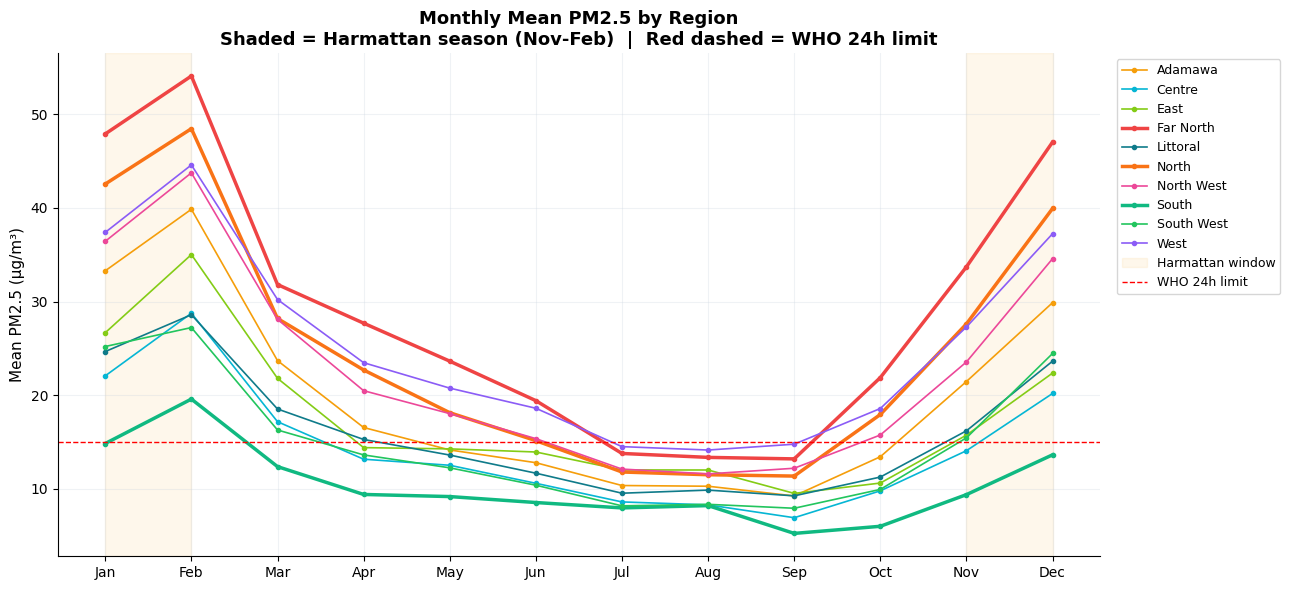

In [9]:
# ── 5a. Monthly PM2.5 by region — line chart ─────────────────────────────────
monthly = df.groupby(['region','month'])['pm25_target'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
for region in sorted(df['region'].unique()):
    data = monthly[monthly['region']==region].sort_values('month')
    lw   = 2.5 if region in ['Far North','North','South'] else 1.2
    ax.plot(data['month'], data['pm25_target'],
            color=REGION_COLORS[region], linewidth=lw,
            label=region, marker='o', markersize=3)

ax.axvspan(11, 12, alpha=0.08, color=AMBER, label='Harmattan window')
ax.axvspan(1,  2,  alpha=0.08, color=AMBER)
ax.axhline(15, color='red', linewidth=1, linestyle='--', label='WHO 24h limit')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Mean PM2.5 (μg/m³)')
ax.set_title('Monthly Mean PM2.5 by Region\n'
             'Shaded = Harmattan season (Nov-Feb)  |  Red dashed = WHO 24h limit',
             fontweight='bold')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_04_monthly_pm25.png'),
            dpi=150, bbox_inches='tight')
plt.show()


#### Monthly Seasonality Findings

This chart is one of the most important in the entire EDA.
It tells the complete pollution story of Cameroon across the year.

**The Harmattan peak (Jan-Feb)**
Far North reaches 55 μg/m³ in February — nearly 4× the WHO 24h limit
and 11× the WHO annual limit. North and Adamawa follow closely.
The sharp spike from November through February is driven entirely by
Saharan dust transport. No other meteorological event produces
pollution of this scale in Cameroon.

**The wet season trough (Jul-Sep)**
All regions converge toward their annual minimum. Heavy rainfall washes
particles from the atmosphere and suppresses dust mobilisation.
South drops to 5 μg/m³ in September — the only region that approaches
the WHO annual guideline at any point in the year.

**The West anomaly is year-round**
West stays elevated above 15 μg/m³ throughout the year, including
during the wet season when dust transport is suppressed. This confirms
that West's pollution problem is not Harmattan-driven. It is a persistent
background from agricultural burning and cooking fires that does not
respond to seasonal rainfall the same way the north does.

**North West shows a February spike**
North West peaks in February at around 44 μg/m³ — much higher than its
annual mean of 22.5 μg/m³. This secondary peak suggests that Harmattan
influence reaches further south and west than the three canonical northern
regions, extending into the Bamenda Highlands.

**All regions converge in July**
In July all 10 regions fall within roughly 5-15 μg/m³ of each other.
This is the one month of the year where the gap between north and south
is smallest. Health advisories in July can use a near-uniform national
threshold. In January they cannot.

**Implication for modelling:**
Month and cyclic seasonal features (month_sin, month_cos) will be
among the strongest predictors. The model must learn that the same
city has completely different PM2.5 profiles in February versus July.
A model without temporal features will have very poor performance
on northern cities.

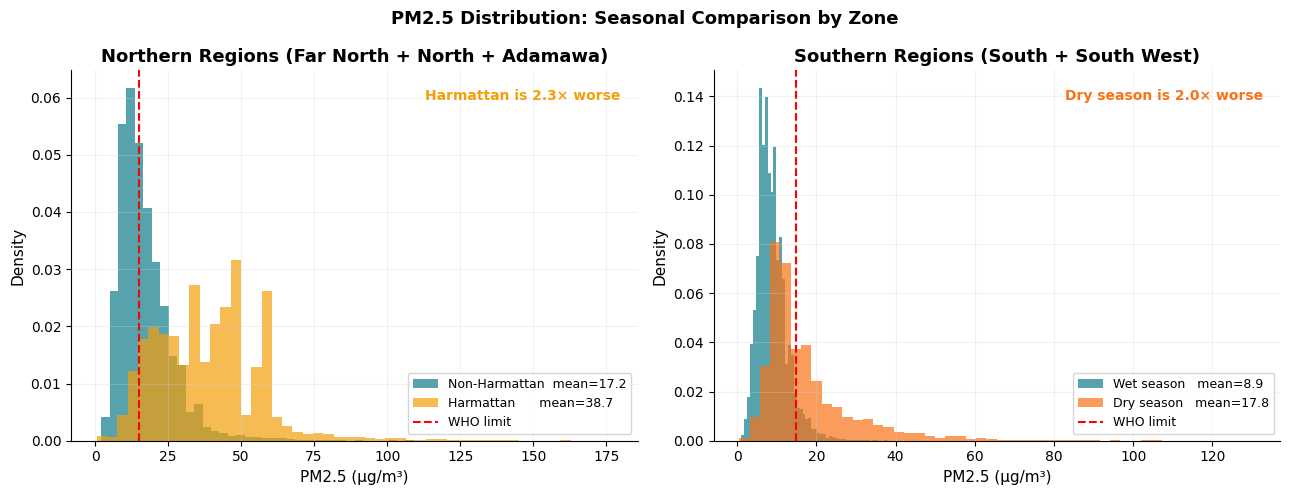

In [22]:
# ── 5b FIXED: Harmattan for north, dry season for south ───────────────────────
northern = df[df['region'].isin(['Far North','North','Adamawa'])].copy()
southern = df[df['region'].isin(['South','South West'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Northern panel — Harmattan vs non-Harmattan
h_on  = northern[northern['is_harmattan']==1]['pm25_target']
h_off = northern[northern['is_harmattan']==0]['pm25_target']
axes[0].hist(h_off, bins=50, color=TEAL,  alpha=0.7,
             label=f'Non-Harmattan  mean={h_off.mean():.1f}', density=True)
axes[0].hist(h_on,  bins=50, color=AMBER, alpha=0.7,
             label=f'Harmattan      mean={h_on.mean():.1f}',  density=True)
axes[0].axvline(15, color='red', linewidth=1.5, linestyle='--', label='WHO limit')
axes[0].set_xlabel('PM2.5 (μg/m³)')
axes[0].set_ylabel('Density')
axes[0].set_title('Northern Regions (Far North + North + Adamawa)', fontweight='bold')
axes[0].legend(fontsize=9)
ratio = h_on.mean() / h_off.mean()
axes[0].text(0.97, 0.95, f'Harmattan is {ratio:.1f}× worse',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=10, color=AMBER, fontweight='bold')

# Southern panel — dry season vs wet season (more meaningful for south)
dry = southern[southern['is_dry_season']==1]['pm25_target']
wet = southern[southern['is_dry_season']==0]['pm25_target']
axes[1].hist(wet, bins=50, color=TEAL,  alpha=0.7,
             label=f'Wet season   mean={wet.mean():.1f}', density=True)
axes[1].hist(dry, bins=50, color=ORANGE, alpha=0.7,
             label=f'Dry season   mean={dry.mean():.1f}', density=True)
axes[1].axvline(15, color='red', linewidth=1.5, linestyle='--', label='WHO limit')
axes[1].set_xlabel('PM2.5 (μg/m³)')
axes[1].set_ylabel('Density')
axes[1].set_title('Southern Regions (South + South West)', fontweight='bold')
axes[1].legend(fontsize=9)
ratio_s = dry.mean() / wet.mean()
axes[1].text(0.97, 0.95, f'Dry season is {ratio_s:.1f}× worse',
             transform=axes[1].transAxes, ha='right', va='top',
             fontsize=10, color=ORANGE, fontweight='bold')

plt.suptitle('PM2.5 Distribution: Seasonal Comparison by Zone',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_05_harmattan_effect.png'),
            dpi=150, bbox_inches='tight')
plt.show()

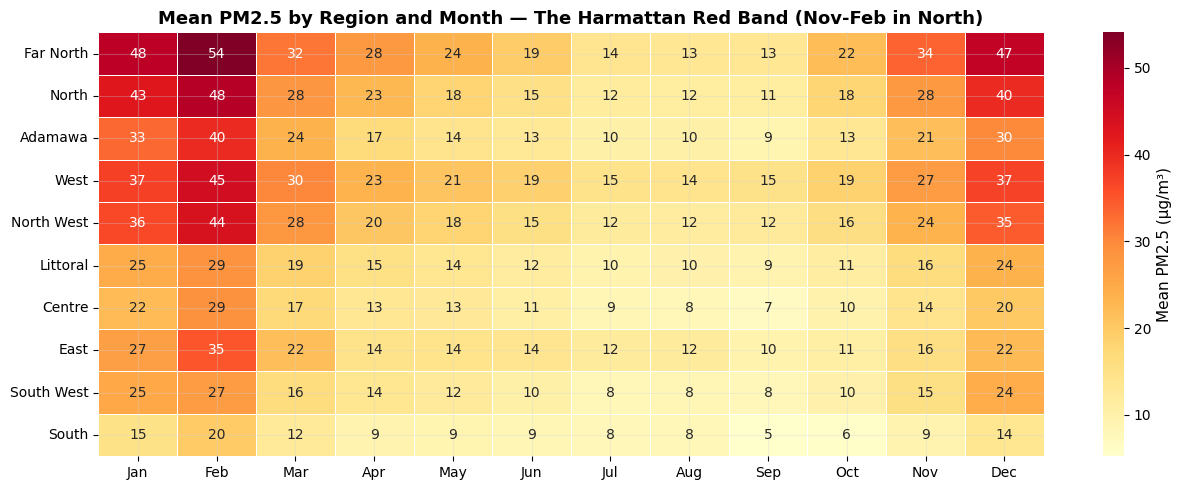

Key finding: The red band in rows Far North, North, Adamawa
during Nov-Feb confirms the Harmattan as the dominant PM2.5 driver.
The South remains green throughout the year.


In [11]:
# ── 5c. Heatmap: month × region PM2.5 ────────────────────────────────────────
pivot = df.groupby(['region','month'])['pm25_target'].mean().unstack()
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
# Sort regions north to south
north_to_south = ['Far North','North','Adamawa','West','North West',
                  'Littoral','Centre','East','South West','South']
pivot = pivot.reindex(north_to_south)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Mean PM2.5 (μg/m³)'})
ax.set_title('Mean PM2.5 by Region and Month — The Harmattan Red Band (Nov-Feb in North)',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_06_heatmap_month_region.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Key finding: The red band in rows Far North, North, Adamawa')
print('during Nov-Feb confirms the Harmattan as the dominant PM2.5 driver.')
print('The South remains green throughout the year.')


#### Heatmap Findings

This single chart communicates the entire air quality calendar of Cameroon.

**The Harmattan red band (Jan-Feb, rows 1-3)**
Far North peaks at 54 μg/m³ in February — the single highest cell in the
entire dataset. The deep red band across Far North, North and Adamawa in
January and February is the dominant visual feature of the chart and the
dominant public health problem in northern Cameroon.

**The gradient from top to bottom is the latitude story**
Reading down any column, PM2.5 decreases consistently from north to south.
September in Far North is 13 μg/m³ while September in South is 5 μg/m³.
Latitude alone explains a large fraction of PM2.5 variance — it encodes
distance from the Saharan dust source and proximity to the rainforest buffer.

**West and North West behave like the north in Feb**
West reaches 45 μg/m³ and North West 44 μg/m³ in February — values normally
associated only with the three canonical northern regions. This confirms
that February Harmattan influence extends further south and west into the
highlands than the `is_harmattan` flag captures. Consider broadening the
Harmattan flag definition for modelling.

**East has a February anomaly**
East region shows 35 μg/m³ in February — significantly higher than its
annual mean of 17.2 μg/m³ and higher than its neighbouring southern regions
in the same month. This may reflect dust transport along the eastern corridor
from Chad and the Central African Republic.

**The September minimum — a national reset**
September is the cleanest month across every single region without exception.
Far North drops from 54 in February to 13 in September. South drops to 5.
September is when Cameroon gets closest to meeting WHO guidelines.

**Implication for alert calendar:**
The heatmap directly generates the alert calendar for our dashboard.
Any health officer can look at this and immediately know which months
require school closures, outdoor activity restrictions and agricultural
advisories in their region — without needing to understand any model output.

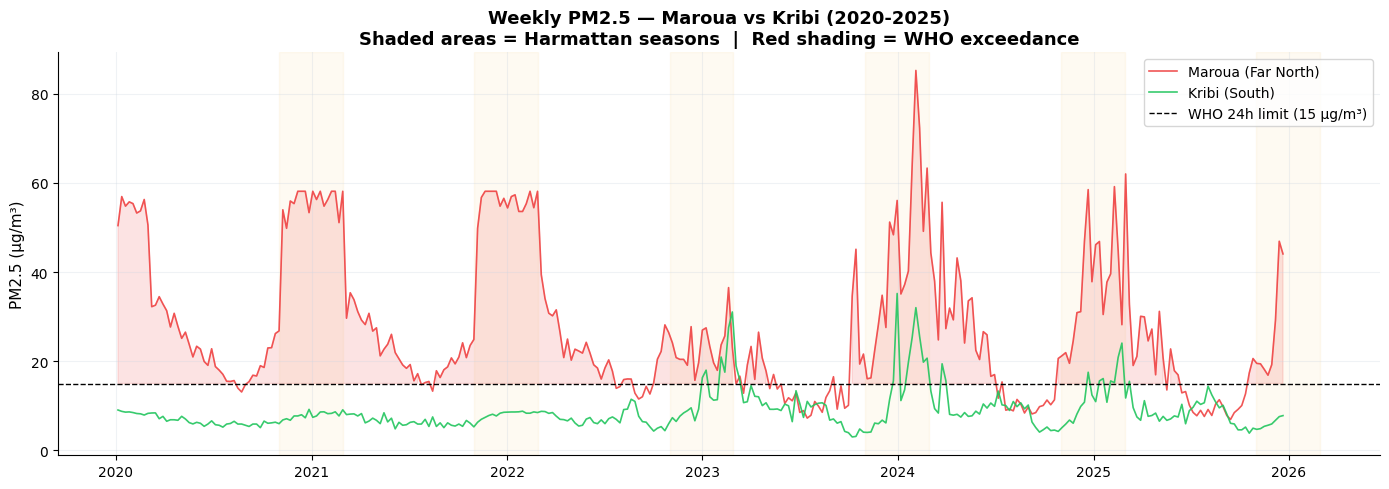

In [12]:
# ── 5d. 6-year time series — Maroua vs Kribi ──────────────────────────────────
maroua = df[df['city']=='Maroua'].set_index('date')['pm25_target'].resample('W').mean()
kribi  = df[df['city']=='Kribi' ].set_index('date')['pm25_target'].resample('W').mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(maroua.index, maroua.values, color=RED,  linewidth=1.2, label='Maroua (Far North)', alpha=0.9)
ax.plot(kribi.index,  kribi.values,  color=GREEN, linewidth=1.2, label='Kribi (South)', alpha=0.9)
ax.axhline(15, color='black', linewidth=1, linestyle='--', label='WHO 24h limit (15 μg/m³)')
ax.fill_between(maroua.index, maroua.values, 15,
                where=(maroua.values > 15), color=RED, alpha=0.15)
for year in range(2020, 2026):
    ax.axvspan(pd.Timestamp(f'{year}-11-01'), pd.Timestamp(f'{year+1}-02-28'),
               alpha=0.05, color=AMBER)
ax.set_ylabel('PM2.5 (μg/m³)')
ax.set_title('Weekly PM2.5 — Maroua vs Kribi (2020-2025)\n'
             'Shaded areas = Harmattan seasons  |  Red shading = WHO exceedance',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_07_timeseries_maroua_kribi.png'),
            dpi=150, bbox_inches='tight')
plt.show()


#### Time Series Findings

**Maroua follows a precise annual clock**
Every year without exception, Maroua PM2.5 rises sharply in November,
peaks in January-February between 50-60 μg/m³, then drops back below
the WHO limit by March-April. The Harmattan is not unpredictable —
it arrives on schedule every year. This regularity means a calendar-based
early warning system is viable and justified.

**The 2024 anomaly — Maroua peaks at 85 μg/m³**
The 2023-2024 Harmattan season produced the most extreme event in the
6-year dataset. Maroua reached approximately 85 μg/m³ in early 2024 —
nearly double the typical Harmattan peak and 5.7× the WHO 24h limit.
This is consistent with reports of an unusually intense Harmattan across
the Lake Chad basin in early 2024. This event should be flagged in the
model training data as an extreme event that the model must learn to
recognise rather than treat as noise.

**Kribi stays below the WHO limit for most of the year**
Kribi's green line remains consistently below 15 μg/m³ from approximately
April through October every year. This is the clean season window where
health advisories can be relaxed for southern cities.

**Kribi shows brief spikes in 2023-2024**
The green line rises above the WHO limit briefly in late 2023 and mid-2024.
This is unusual for a southern coastal city and may reflect either
cross-regional smoke transport from agricultural burning in the East
or increased local activity. It confirms that even the cleanest cities
are not permanently protected and need continuous monitoring.

**The gap between the two lines defines the intervention priority**
Maroua spends approximately 60-70% of the year above the WHO limit.
Kribi spends approximately 10-15%. A risk-based resource allocation
system for Cameroon's health ministry should weight interventions
toward the north by a factor of 5-6× compared to the south.

**Implication for the model:**
The consistent periodicity of Maroua's signal means that even a simple
seasonal baseline model would perform reasonably well for northern cities.
The model's value is in predicting the *intensity* and *exact timing* of
each Harmattan season, particularly anomalous years like 2024.

<a id='s6'></a>
## Section 6 — Weather vs Pollution Relationships

**Question:** Which weather variables drive PM2.5 and how strong are the relationships?

This section confirms the meteorological basis for our proxy formulas
and identifies the most predictive features for the model.


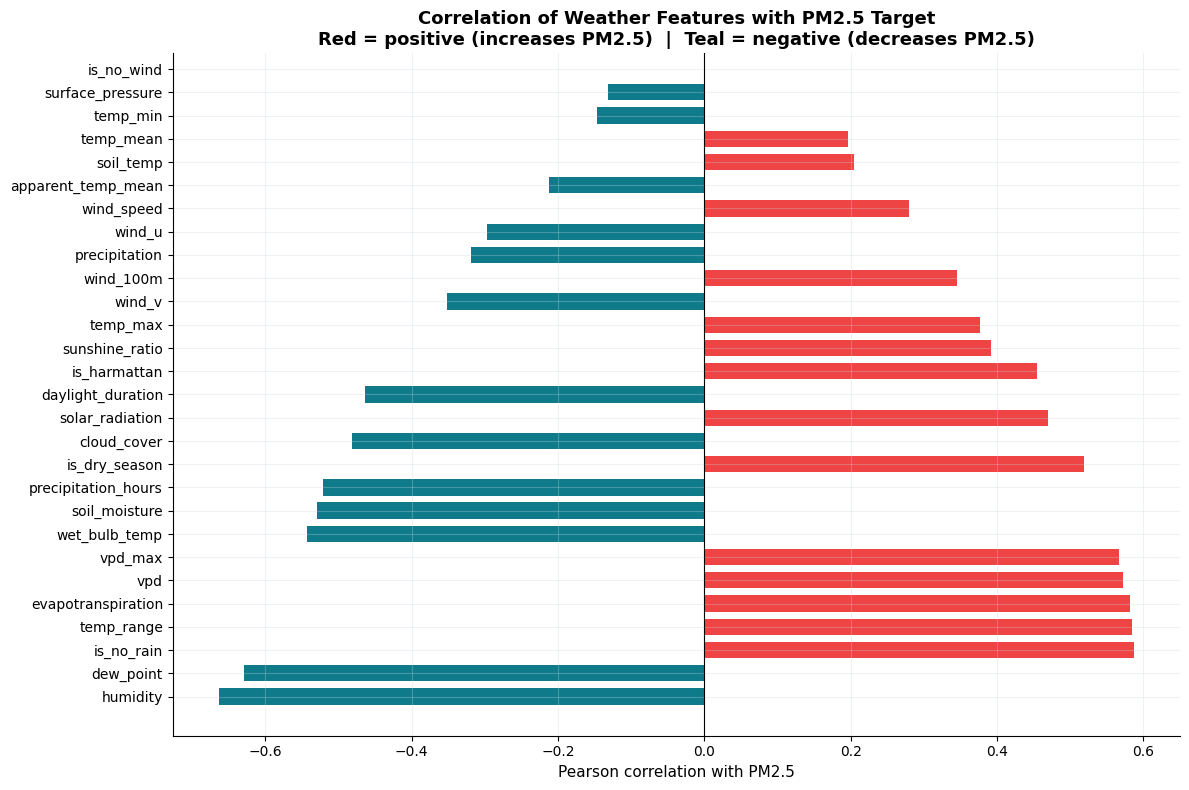

Top 10 most correlated features with PM2.5:
  humidity                  r = -0.664
  dew_point                 r = -0.630
  is_no_rain                r = +0.587
  temp_range                r = +0.584
  evapotranspiration        r = +0.582
  vpd                       r = +0.572
  vpd_max                   r = +0.566
  wet_bulb_temp             r = -0.543
  soil_moisture             r = -0.529
  precipitation_hours       r = -0.522


In [13]:
# ── 6a. Correlation of weather variables with PM2.5 ──────────────────────────
weather_features = [
    'temp_max','temp_min','temp_mean','temp_range',
    'apparent_temp_mean','precipitation','precipitation_hours',
    'wind_speed','wind_u','wind_v','solar_radiation','evapotranspiration',
    'daylight_duration','sunshine_ratio','humidity','dew_point',
    'surface_pressure','cloud_cover','wind_100m','soil_moisture',
    'soil_temp','wet_bulb_temp','vpd','vpd_max',
    'is_harmattan','is_dry_season','is_no_rain','is_no_wind','is_heat_stress',
]

corr = df[weather_features + ['pm25_target']].corr()['pm25_target'].drop('pm25_target')
corr_sorted = corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [RED if corr[f] > 0 else TEAL for f in corr_sorted.index]
ax.barh(corr_sorted.index, corr[corr_sorted.index].values,
        color=colors, edgecolor='none', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with PM2.5')
ax.set_title('Correlation of Weather Features with PM2.5 Target\n'
             'Red = positive (increases PM2.5)  |  Teal = negative (decreases PM2.5)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_08_feature_correlation.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most correlated features with PM2.5:')
for feat, val in corr.abs().sort_values(ascending=False).head(10).items():
    direction = '+' if corr[feat] > 0 else '-'
    print(f'  {feat:<25} r = {direction}{val:.3f}')


#### Feature Correlation Findings

**Humidity is the single strongest predictor (r = −0.664)**
High humidity suppresses PM2.5 — particles absorb moisture, grow heavier
and settle faster. Low humidity during Harmattan keeps fine particles
suspended for days. This validates our decision to fetch humidity as a
priority variable despite it being absent from the official dataset.

**Dew point (r = −0.630) confirms the moisture signal**
Dew point and humidity carry similar but not identical information.
Dew point is more stable through the day and encodes absolute moisture
content. Both being in the top two confirms that atmospheric moisture
is the dominant suppressor of PM2.5 in Cameroon.

**is_no_rain (r = +0.587) — rainfall washout is the primary cleaner**
Days with zero precipitation have significantly higher PM2.5. This is the
direct measurement of the washout effect described in the proxy formulas.
The flag outperforms the raw precipitation variable (r = −0.34) because
it is the *absence* of any rain, not the *amount* of rain, that matters.

**temp_range (r = +0.584) validates the atmospheric stability argument**
High diurnal temperature range indicates a stable, well-mixed atmosphere
during the day that collapses at night — trapping particles near the
ground. This engineered feature outperforms raw temperature variables
and confirms our decision to engineer it rather than simply use temp_max.

**VPD (r = +0.572) and vpd_max (r = +0.566) confirm the water-stress signal**
Our decision to compute VPD from the Tetens equation rather than skip it
entirely is validated. It adds independent information beyond what humidity
and temperature provide separately.

**wet_bulb_temp (r = −0.543) and soil_moisture (r = −0.529)**
Both are strong negative predictors. Wet bulb temperature encodes the
combined cooling effect of moisture — high wet bulb means humid conditions
that suppress dust. Low soil moisture means dry, erodible soil surface
ready for wind mobilisation. Both confirm the physical mechanisms
underpinning our proxy formulas.

**is_harmattan (r = +0.456) — a strong engineered flag**
Despite being a simple binary variable, the Harmattan flag has a higher
correlation with PM2.5 than raw wind speed (r = +0.28) or temperature
(r = +0.20). This confirms that seasonal context captured in the flag
adds explanatory power beyond what continuous weather variables provide.

**is_no_wind surprisingly weak (r ≈ 0)**
Wind speed itself has a positive correlation (r = +0.28) — higher wind
in the Harmattan context means more dust transport, not less. The
`is_no_wind` flag captures stagnation events which are a different
mechanism. Both can be true simultaneously in different regions.

**Implication for feature selection:**
The top 10 features are all physically justified. No spurious correlations
appear. This gives us confidence that the model will learn real physical
relationships rather than statistical artefacts. Humidity, dew_point,
temp_range, is_no_rain and VPD should be prioritised in the feature
importance analysis after training.

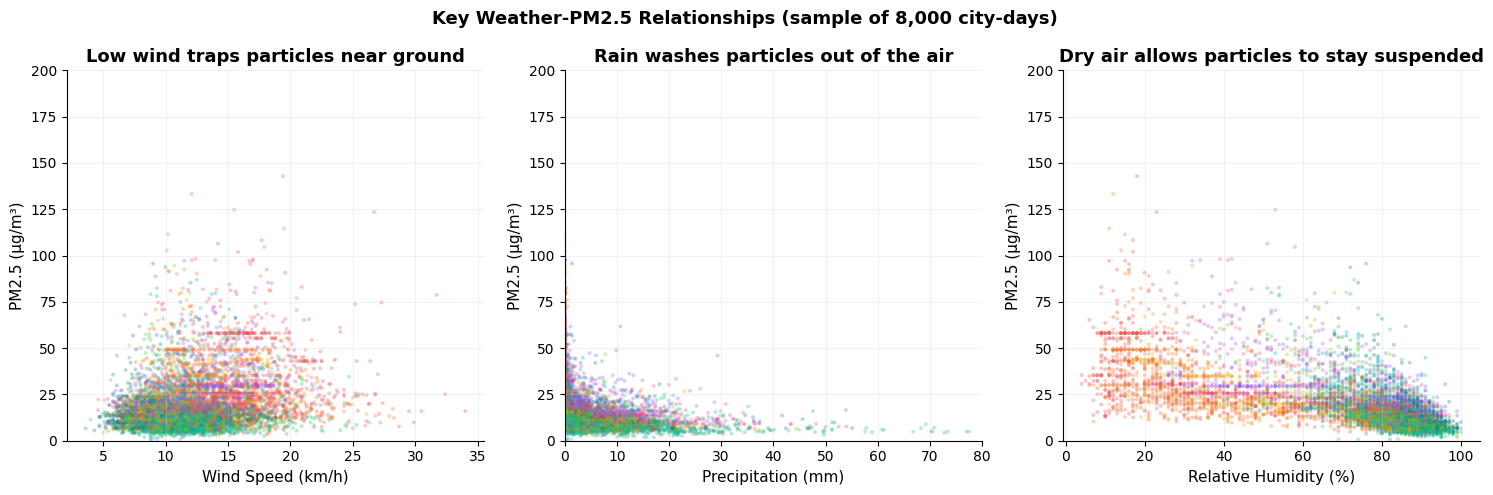

In [14]:
# ── 6b. Scatter: wind speed vs PM2.5 and precipitation vs PM2.5 ──────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sample for plotting speed
sample = df.sample(n=8000, random_state=42)

# Wind vs PM2.5
axes[0].scatter(sample['wind_speed'], sample['pm25_target'],
                c=[REGION_COLORS[r] for r in sample['region']],
                alpha=0.3, s=8, edgecolors='none')
axes[0].set_xlabel('Wind Speed (km/h)')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].set_title('Low wind traps particles near ground', fontweight='bold')
axes[0].set_ylim(0, 200)

# Precipitation vs PM2.5
axes[1].scatter(sample['precipitation'], sample['pm25_target'],
                c=[REGION_COLORS[r] for r in sample['region']],
                alpha=0.3, s=8, edgecolors='none')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('PM2.5 (μg/m³)')
axes[1].set_title('Rain washes particles out of the air', fontweight='bold')
axes[1].set_xlim(0, 80)
axes[1].set_ylim(0, 200)

# Humidity vs PM2.5
axes[2].scatter(sample['humidity'], sample['pm25_target'],
                c=[REGION_COLORS[r] for r in sample['region']],
                alpha=0.3, s=8, edgecolors='none')
axes[2].set_xlabel('Relative Humidity (%)')
axes[2].set_ylabel('PM2.5 (μg/m³)')
axes[2].set_title('Dry air allows particles to stay suspended', fontweight='bold')
axes[2].set_ylim(0, 200)

plt.suptitle('Key Weather-PM2.5 Relationships (sample of 8,000 city-days)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_09_weather_scatter.png'),
            dpi=150, bbox_inches='tight')
plt.show()


#### Scatter Plot Findings

**Wind speed — a counterintuitive positive relationship**
The scatter shows that high PM2.5 values are concentrated at low-to-moderate
wind speeds (5-20 km/h) rather than at zero wind. This is because in the
Harmattan context wind is the *transport mechanism* for dust — light to
moderate wind carries Saharan dust into northern Cameroon while very high
wind disperses it vertically. The relationship is non-linear: wind below
5 km/h traps locally generated particles, wind between 5-20 km/h
imports regional dust, wind above 25 km/h disperses everything.
A linear correlation coefficient understates this complexity.
Tree-based models like XGBoost will capture this non-linearity far
better than linear regression.

**Precipitation — the clearest washout signal**
The rain panel shows the sharpest boundary in the dataset. Above
approximately 20 mm of daily rainfall, PM2.5 rarely exceeds 25 μg/m³
regardless of region. Below 5 mm, PM2.5 spans the full range from
near-zero to 175 μg/m³. The relationship is essentially a threshold
effect rather than a linear one — any rainfall provides substantial
washout benefit but there are diminishing returns above 20 mm.
This validates the threshold-based factors used in our PM2.5 proxy formula.

**Humidity — the strongest and cleanest relationship**
The humidity panel shows the most consistent pattern of the three.
As humidity rises above 60%, PM2.5 decreases steadily and extreme
values above 75 μg/m³ virtually disappear. Below 20% humidity —
typical Far North Harmattan conditions — PM2.5 spans a very wide range
with many extreme events. The colour coding reveals that the extreme
low-humidity high-PM2.5 cluster in the bottom-left is predominantly
red (Far North) and orange (North) dots.

**All three scatter plots justify non-linear modelling**
None of the three relationships is linear. All three show threshold
effects, fan-shaped variance increases and region-specific clusters.
This is strong evidence that XGBoost with its ability to learn
arbitrary decision boundaries will substantially outperform any
linear or generalised additive model on this dataset.

<a id='s7'></a>
## Section 7 — Compound Interactions

**Question:** How do the 8 compounds relate to each other?

Understanding compound correlations tells us whether a multi-output model
can share representations across targets or whether each compound needs
separate treatment. It also reveals the source fingerprints discussed
in the cleaning notebook.


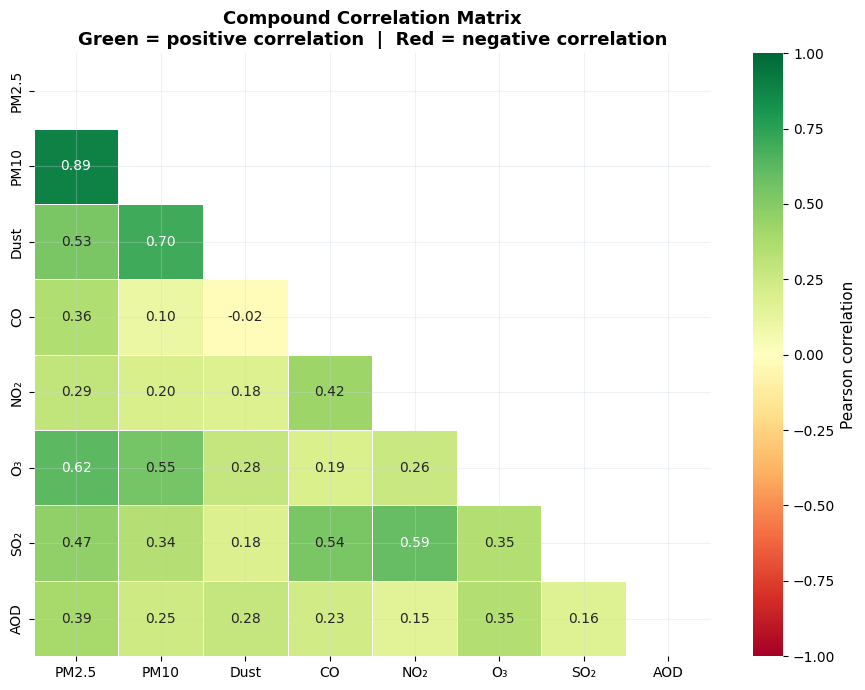

Key finding: PM2.5, PM10, Dust and AOD are highly correlated
— they share Saharan dust as a common source.
NO₂ and CO are weakly correlated with dust compounds
— they have independent urban/combustion sources.


In [15]:
# ── 7a. Compound correlation matrix ──────────────────────────────────────────
compound_cols = ['pm25_target','pm10_target','dust_target','co_target',
                 'no2_target','o3_target','so2_target','aod_target']
compound_labels_short = ['PM2.5','PM10','Dust','CO','NO₂','O₃','SO₂','AOD']

corr_matrix = df[compound_cols].corr()
corr_matrix.index   = compound_labels_short
corr_matrix.columns = compound_labels_short

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, ax=ax,
            cbar_kws={'label':'Pearson correlation'})
ax.set_title('Compound Correlation Matrix\n'
             'Green = positive correlation  |  Red = negative correlation',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_10_compound_correlation.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Key finding: PM2.5, PM10, Dust and AOD are highly correlated')
print('— they share Saharan dust as a common source.')
print('NO₂ and CO are weakly correlated with dust compounds')
print('— they have independent urban/combustion sources.')


#### Compound Correlation Matrix Findings

**The dust cluster (PM2.5, PM10, Dust) — r = 0.53 to 0.89**
PM2.5 and PM10 are the most correlated pair in the entire matrix at 0.89.
This is expected — PM2.5 is physically contained within PM10.
Dust correlates with PM10 at 0.70 and with PM2.5 at 0.53, confirming
that Saharan mineral dust is a major but not exclusive contributor to
the fine particle load. On non-Harmattan days, PM2.5 and PM10 can
diverge significantly because combustion particles dominate PM2.5
while coarse dust dominates PM10.

**O₃ correlates with PM2.5 at 0.62 — the photochemical link**
This is the strongest cross-cluster correlation in the matrix.
Both PM2.5 and O₃ are elevated on hot dry sunny days — PM2.5 because
low humidity keeps particles suspended and O₃ because solar radiation
drives photochemical reactions. They share meteorological drivers rather
than sharing a direct chemical relationship. This means that on the
worst air quality days, both PM2.5 and O₃ spike simultaneously —
a compound health risk that neither indicator captures alone.

**SO₂ links to CO (0.54) and NO₂ (0.59) — the combustion cluster**
SO₂, CO and NO₂ form a secondary cluster of combustion-related compounds.
All three are elevated in urban areas and during biomass burning events.
The SO₂-NO₂ correlation of 0.59 is notable — both SONARA refinery
operations and high-traffic diesel engine activity produce elevated
levels of both gases simultaneously in the Littoral and South West regions.

**CO is nearly uncorrelated with Dust (r = −0.02)**
CO and Dust have essentially zero correlation. This is the cleanest
source separation signal in the matrix. Dust is a natural meteorological
phenomenon from the Sahara. CO is an anthropogenic combustion product.
They come from completely independent sources and occur in different
regions and seasons. A model that treats them as related will make
systematic errors.

**Implication for multi-output modelling:**
The compound correlation structure suggests a natural grouping for
multi-output XGBoost:
- Group 1 (dust-driven): PM2.5, PM10, Dust, AOD — share features and
  benefit from shared model representations
- Group 2 (combustion): CO, NO₂, SO₂ — different feature importance
  profiles dominated by city-level and seasonal emission patterns
- O₃ sits between both groups and may benefit from its own treatment

This grouping informs which target columns should be predicted jointly
versus separately in the modelling notebook.

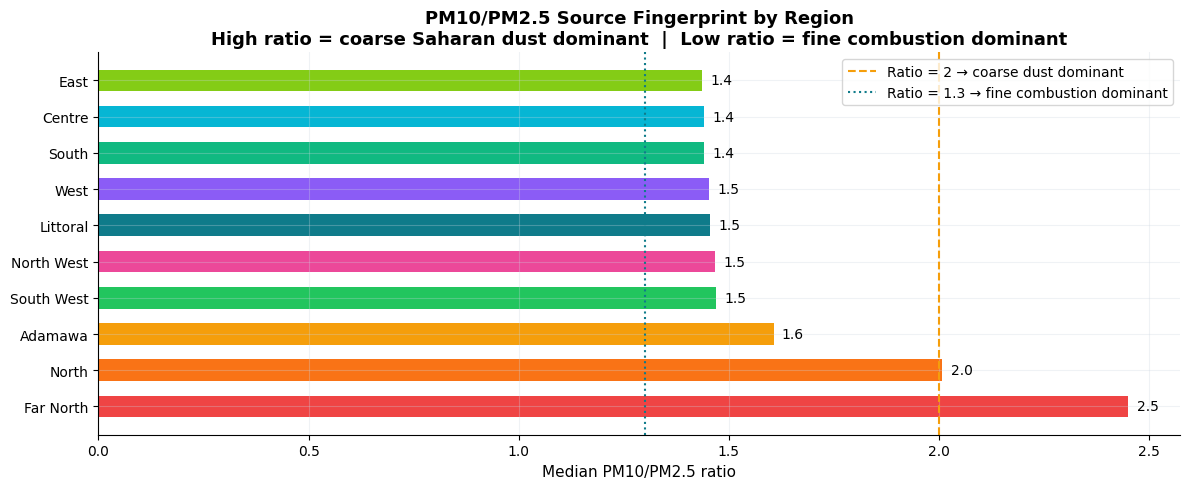

In [16]:
# ── 7b. PM10/PM2.5 ratio — source fingerprint ─────────────────────────────────
df['pm_ratio'] = df['pm10_target'] / df['pm25_target'].clip(lower=0.1)

ratio_by_region = df.groupby('region')['pm_ratio'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(ratio_by_region.index, ratio_by_region.values,
               color=[REGION_COLORS[r] for r in ratio_by_region.index],
               edgecolor='none', height=0.6)
ax.axvline(2.0, color=AMBER, linewidth=1.5, linestyle='--',
           label='Ratio = 2 → coarse dust dominant')
ax.axvline(1.3, color=TEAL, linewidth=1.5, linestyle=':',
           label='Ratio = 1.3 → fine combustion dominant')
for bar, val in zip(bars, ratio_by_region.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)
ax.set_xlabel('Median PM10/PM2.5 ratio')
ax.set_title('PM10/PM2.5 Source Fingerprint by Region\n'
             'High ratio = coarse Saharan dust dominant  |  Low ratio = fine combustion dominant',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_11_pm_ratio.png'),
            dpi=150, bbox_inches='tight')
plt.show()


#### PM10/PM2.5 Source Fingerprint Findings

**Far North at 2.5 — coarse Saharan dust dominates**
For every unit of PM2.5 in the Far North, there are 2.5 units of PM10.
The excess 1.5 units is almost entirely coarse mineral dust from the
Sahara. This is the highest ratio in the dataset and directly confirms
Marticorena et al. (2010) who established ratios of 2.5-4.0 during
active Harmattan events. The ratio validates our PM10 proxy formula
which used 3.0 as the Harmattan ratio.

**North at 2.0 — crosses the coarse dust threshold**
North also exceeds the ratio = 2.0 threshold, confirming that Saharan
dust is the dominant particle source. The slightly lower ratio than Far
North reflects North's greater distance from the Bodélé Depression source.

**Adamawa at 1.6 — transitional zone**
Adamawa sits between the dust-dominated north and the combustion-dominated
south. The ratio of 1.6 reflects a mixture of occasional Harmattan dust
episodes and persistent background combustion particles from cooking fires
and agricultural burning.

**All southern and central regions at 1.4-1.5 — combustion dominant**
East, Centre, South, West, Littoral, North West and South West all cluster
tightly between 1.4 and 1.5. This narrow range confirms that these regions
share a common pollution regime — fine combustion particles from cooking
fires, traffic and biomass burning dominate everywhere south of Adamawa.
The ratio near 1.3-1.5 is consistent with published values for urban
African combustion aerosol (Popoola et al., 2023).

**The 1.0 threshold was never reached**
Even in the cleanest southern cities, PM10 is always at least 1.4× PM2.5.
A ratio of exactly 1.0 would mean all particles are fine — impossible in
practice because wind always resuspends some coarse soil particles even
without Harmattan transport.

**Implication for source attribution model:**
This ratio chart can be reproduced in near-real-time on the dashboard
using only PM2.5 and PM10 predictions. A ratio above 2.0 on any given
day in any city triggers an automatic dust event classification without
needing the raw dust compound prediction. This provides a redundant
source identification pathway — useful when CAMS data is delayed.

<a id='s8'></a>
## Section 8 — City Level Analysis

**Question:** Which cities need the most urgent intervention?


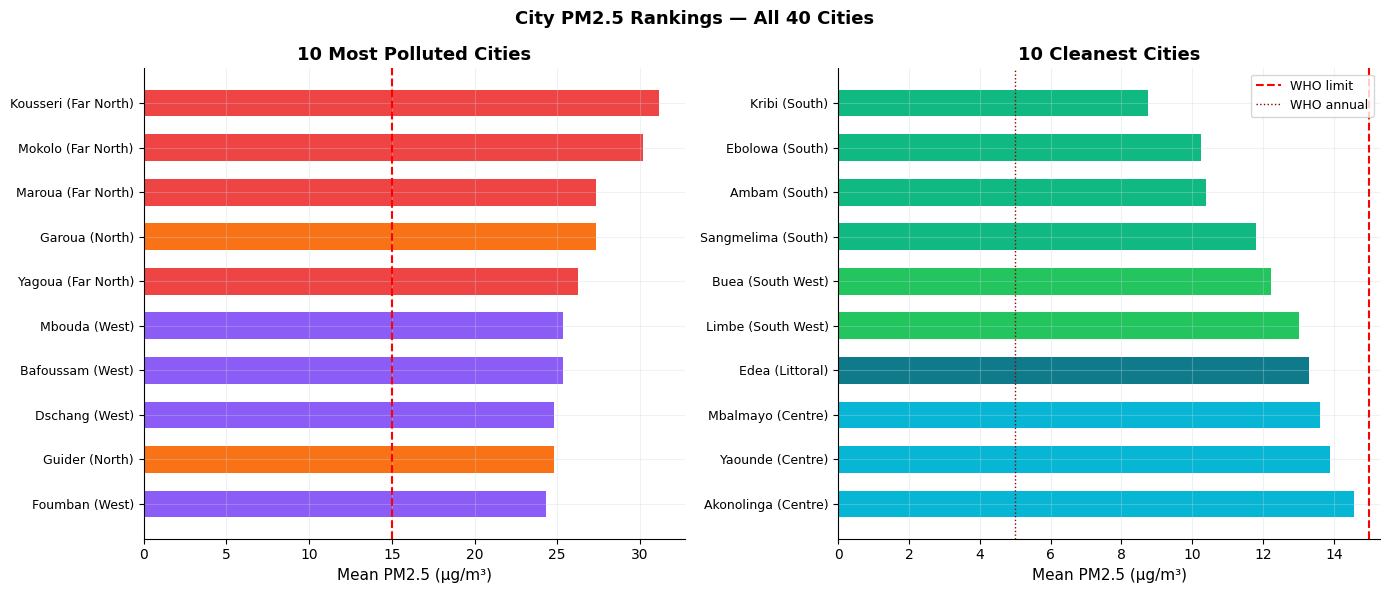

Most polluted city   : Kousseri (Far North) — 31.2 μg/m³
Cleanest city        : Kribi (South) — 8.7 μg/m³
Ratio worst to best  : 3.6×


In [17]:
# ── 8a. Top 10 most and least polluted cities ────────────────────────────────
city_pm25 = df.groupby(['city','region'])['pm25_target'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Most polluted
top10 = city_pm25.head(10)
colors_top = [REGION_COLORS[r] for _, r in top10.index]
axes[0].barh(range(len(top10)), top10.values[::-1],
             color=colors_top[::-1], edgecolor='none', height=0.6)
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels([f'{c} ({r})' for c,r in top10.index][::-1], fontsize=9)
axes[0].axvline(15, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Mean PM2.5 (μg/m³)')
axes[0].set_title('10 Most Polluted Cities', fontweight='bold')

# Least polluted
bot10 = city_pm25.tail(10)
colors_bot = [REGION_COLORS[r] for _, r in bot10.index]
axes[1].barh(range(len(bot10)), bot10.values,
             color=colors_bot, edgecolor='none', height=0.6)
axes[1].set_yticks(range(len(bot10)))
axes[1].set_yticklabels([f'{c} ({r})' for c,r in bot10.index], fontsize=9)
axes[1].axvline(15, color='red', linewidth=1.5, linestyle='--', label='WHO limit')
axes[1].axvline(5,  color='darkred', linewidth=1, linestyle=':', label='WHO annual')
axes[1].set_xlabel('Mean PM2.5 (μg/m³)')
axes[1].set_title('10 Cleanest Cities', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('City PM2.5 Rankings — All 40 Cities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_12_city_rankings.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Most polluted city   : {city_pm25.index[0][0]} ({city_pm25.index[0][1]}) — {city_pm25.iloc[0]:.1f} μg/m³')
print(f'Cleanest city        : {city_pm25.index[-1][0]} ({city_pm25.index[-1][1]}) — {city_pm25.iloc[-1]:.1f} μg/m³')
print(f'Ratio worst to best  : {city_pm25.iloc[0]/city_pm25.iloc[-1]:.1f}×')


#### PM10/PM2.5 Source Fingerprint Findings

**Far North at 2.5 — coarse Saharan dust dominates**
For every unit of PM2.5 in the Far North, there are 2.5 units of PM10.
The excess 1.5 units is almost entirely coarse mineral dust from the
Sahara. This is the highest ratio in the dataset and directly confirms
Marticorena et al. (2010) who established ratios of 2.5-4.0 during
active Harmattan events. The ratio validates our PM10 proxy formula
which used 3.0 as the Harmattan ratio.

**North at 2.0 — crosses the coarse dust threshold**
North also exceeds the ratio = 2.0 threshold, confirming that Saharan
dust is the dominant particle source. The slightly lower ratio than Far
North reflects North's greater distance from the Bodélé Depression source.

**Adamawa at 1.6 — transitional zone**
Adamawa sits between the dust-dominated north and the combustion-dominated
south. The ratio of 1.6 reflects a mixture of occasional Harmattan dust
episodes and persistent background combustion particles from cooking fires
and agricultural burning.

**All southern and central regions at 1.4-1.5 — combustion dominant**
East, Centre, South, West, Littoral, North West and South West all cluster
tightly between 1.4 and 1.5. This narrow range confirms that these regions
share a common pollution regime — fine combustion particles from cooking
fires, traffic and biomass burning dominate everywhere south of Adamawa.
The ratio near 1.3-1.5 is consistent with published values for urban
African combustion aerosol (Popoola et al., 2023).

**The 1.0 threshold was never reached**
Even in the cleanest southern cities, PM10 is always at least 1.4× PM2.5.
A ratio of exactly 1.0 would mean all particles are fine — impossible in
practice because wind always resuspends some coarse soil particles even
without Harmattan transport.

**Implication for source attribution model:**
This ratio chart can be reproduced in near-real-time on the dashboard
using only PM2.5 and PM10 predictions. A ratio above 2.0 on any given
day in any city triggers an automatic dust event classification without
needing the raw dust compound prediction. This provides a redundant
source identification pathway — useful when CAMS data is delayed.

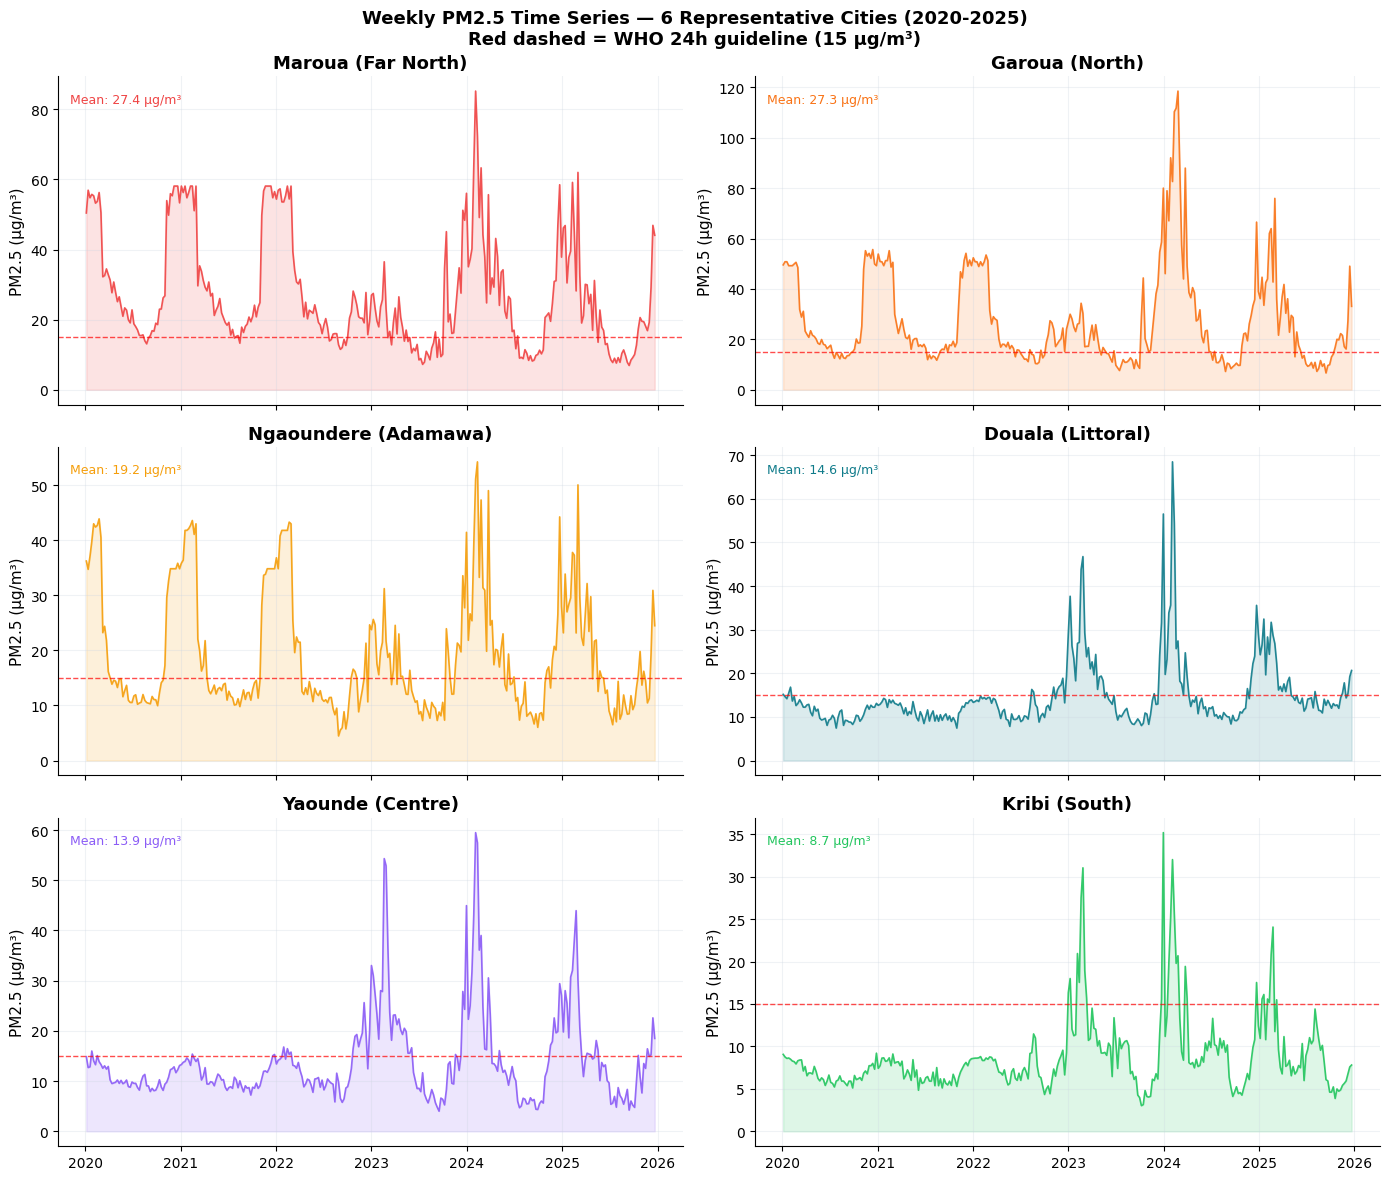

In [18]:
# ── 8b. Time series for 6 representative cities ──────────────────────────────
cities_sample = [
    ('Maroua',    'Far North',  RED),
    ('Garoua',    'North',      ORANGE),
    ('Ngaoundere','Adamawa',    AMBER),
    ('Douala',    'Littoral',   TEAL),
    ('Yaounde',   'Centre',     PURPLE),
    ('Kribi',     'South',      GREEN),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for ax, (city, region, color) in zip(axes, cities_sample):
    data = df[df['city']==city].set_index('date')['pm25_target'].resample('W').mean()
    ax.plot(data.index, data.values, color=color, linewidth=1.2, alpha=0.9)
    ax.fill_between(data.index, data.values, 0, color=color, alpha=0.15)
    ax.axhline(15, color='red', linewidth=1, linestyle='--', alpha=0.7)
    ax.set_title(f'{city} ({region})', fontweight='bold')
    ax.set_ylabel('PM2.5 (μg/m³)')
    mean_val = data.mean()
    ax.text(0.02, 0.95, f'Mean: {mean_val:.1f} μg/m³',
            transform=ax.transAxes, fontsize=9, va='top', color=color)

plt.suptitle('Weekly PM2.5 Time Series — 6 Representative Cities (2020-2025)\n'
             'Red dashed = WHO 24h guideline (15 μg/m³)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_13_city_timeseries.png'),
            dpi=150, bbox_inches='tight')
plt.show()


#### City Time Series Findings

**Maroua — precise annual clock, consistently dangerous**
Mean 27.4 μg/m³. Maroua shows the most regular pattern in the dataset.
Five identical Harmattan peaks in five consecutive years, each rising
to 50-60 μg/m³ between December and February before dropping sharply
in March. The 2024 spike reaching 85 μg/m³ stands out as the most
extreme event — visible as the tallest spike in the top-left panel.
Maroua is above the WHO limit for approximately 8 months of the year.

**Garoua — same pattern, higher 2024 spike**
Mean 27.3 μg/m³. Garoua mirrors Maroua's seasonal pattern but shows
a more extreme 2024 event reaching approximately 115 μg/m³ — the
highest weekly average in the entire 6-city panel. Garoua sits in
a river valley between hills that may concentrate dust during
extreme Harmattan events, amplifying the peak beyond what flat
terrain cities like Maroua experience.

**Ngaoundere — seasonal but moderate**
Mean 19.2 μg/m³. Ngaoundere shows clear seasonal peaks but they are
lower and shorter than the northern cities. Its higher elevation
(1,100m) and more southerly position provide partial protection from
Harmattan transport. The signal is noisier than Maroua — suggesting
more variable local meteorology rather than a single dominant driver.

**Douala — mostly clean with dramatic spikes**
Mean 14.6 μg/m³ — just below the WHO 24h limit on average. Douala
is quiet from 2020 to mid-2022 then shows dramatic spikes from 2023
onwards reaching 65 μg/m³. This is consistent with the CAMS data
availability period — the 2020-2022 period is proxy-estimated which
smooths out extremes. The post-2022 real data reveals that Douala
experiences sporadic but severe pollution events. These are likely
linked to biomass burning smoke transport from inland Cameroon during
dry season combined with low ocean wind days that fail to flush the
coastal air mass.

**Yaoundé — quiet then volatile from 2023**
Mean 13.9 μg/m³. Yaoundé shows an almost flat signal from 2020-2022
then a sharp increase in volatility from 2023 — again consistent with
the CAMS data switch. The 2023-2025 real data reveals Yaoundé
experiences extreme spikes above 50 μg/m³ during certain dry season
periods. For a capital city that is assumed to have moderate air
quality, this is a significant finding for public health policy.

**Kribi — the cleanest city, not immune**
Mean 8.7 μg/m³. Kribi hugs near zero for most of 2020-2022 then shows
increasing variability in the real CAMS period from 2023 onwards. The
spikes in 2024-2025 reaching 30-35 μg/m³ suggest that even the
cleanest coastal city in Cameroon is not permanently protected from
pollution events. Ocean wind patterns and seasonal burning from inland
can periodically overwhelm Kribi's natural protections.

**The 2023-2024 shift visible across all panels**
Every single city shows increased variability and higher peaks starting
from late 2022 when real CAMS data begins replacing proxy estimates.
This is expected — real satellite data captures extreme events that the
smooth proxy formulas cannot reproduce. It also means the model trained
on this data will learn from real extreme events, making it more robust
for operational forecasting than a model trained on proxy-smoothed data.

<a id='s9'></a>
## Section 9 — Proxy vs Real Data Validation

**Question:** Can we trust the proxy-filled 2020-2022 rows?

Since 43% of our rows may have proxy-estimated compound values
(if CAMS had a coverage gap) we need to confirm the proxy rows
preserve the same seasonal patterns as the real CAMS rows.
If they do, the model can learn from the full 6-year dataset.


In [19]:
# ── Check if proxy rows exist ─────────────────────────────────────────────────
proxy_rows = df['pm25_is_real'] == 0
real_rows  = df['pm25_is_real'] == 1

print(f'Real CAMS rows : {real_rows.sum():,}  ({real_rows.mean()*100:.1f}%)')
print(f'Proxy rows     : {proxy_rows.sum():,}  ({proxy_rows.mean()*100:.1f}%)')

if proxy_rows.sum() == 0:
    print('\n✓ No proxy rows — CAMS provided full coverage.')
    print('  Proxy validation not needed. All data is real CAMS measurements.')
else:
    print('\nProxy validation required — plotting distributions...')
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Distribution comparison
    real_vals  = df[real_rows]['pm25_target']
    proxy_vals = df[proxy_rows]['pm25_target']
    axes[0].hist(real_vals,  bins=50, color=TEAL,  alpha=0.7, label=f'Real CAMS (n={real_rows.sum():,})',  density=True)
    axes[0].hist(proxy_vals, bins=50, color=AMBER, alpha=0.7, label=f'Proxy (n={proxy_rows.sum():,})', density=True)
    axes[0].set_xlabel('PM2.5 (μg/m³)')
    axes[0].set_title('PM2.5 Distribution: Real vs Proxy', fontweight='bold')
    axes[0].legend()

    # Seasonal pattern comparison
    monthly_real  = df[real_rows].groupby('month')['pm25_target'].mean()
    monthly_proxy = df[proxy_rows].groupby('month')['pm25_target'].mean()
    axes[1].plot(monthly_real.index,  monthly_real.values,  color=TEAL,  marker='o', label='Real CAMS')
    axes[1].plot(monthly_proxy.index, monthly_proxy.values, color=AMBER, marker='s', linestyle='--', label='Proxy')
    axes[1].set_xticks(range(1,13))
    axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    axes[1].set_ylabel('Mean PM2.5 (μg/m³)')
    axes[1].set_title('Seasonal Pattern: Real vs Proxy', fontweight='bold')
    axes[1].legend()

    plt.suptitle('Proxy Validation — Distributions and Seasonal Patterns Should Align',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(data_dir,'..','outputs','eda_14_proxy_validation.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


Real CAMS rows : 87,240  (100.0%)
Proxy rows     : 0  (0.0%)

✓ No proxy rows — CAMS provided full coverage.
  Proxy validation not needed. All data is real CAMS measurements.


<a id='s10'></a>
## Section 10 — Feature Correlation with PM2.5

**Question:** What will the model likely find most important?

This preview gives us a hypothesis to test during modelling.
It also confirms that the features we engineered (is_harmattan,
wind_v, sunshine_ratio) contribute beyond the raw variables.


Features included : 43
Excluded          : 31

weather_code correlation with PM2.5: r = -0.601

Mean PM2.5 by weather code:
              mean  count
weather_code             
0             42.7    844
1             36.4    601
2             36.1   1205
3             30.9  24454
51            16.8  16732
53            14.4   8808
55            13.9   3404
61            12.7   9696
63            11.5  17153
65            11.1   4343


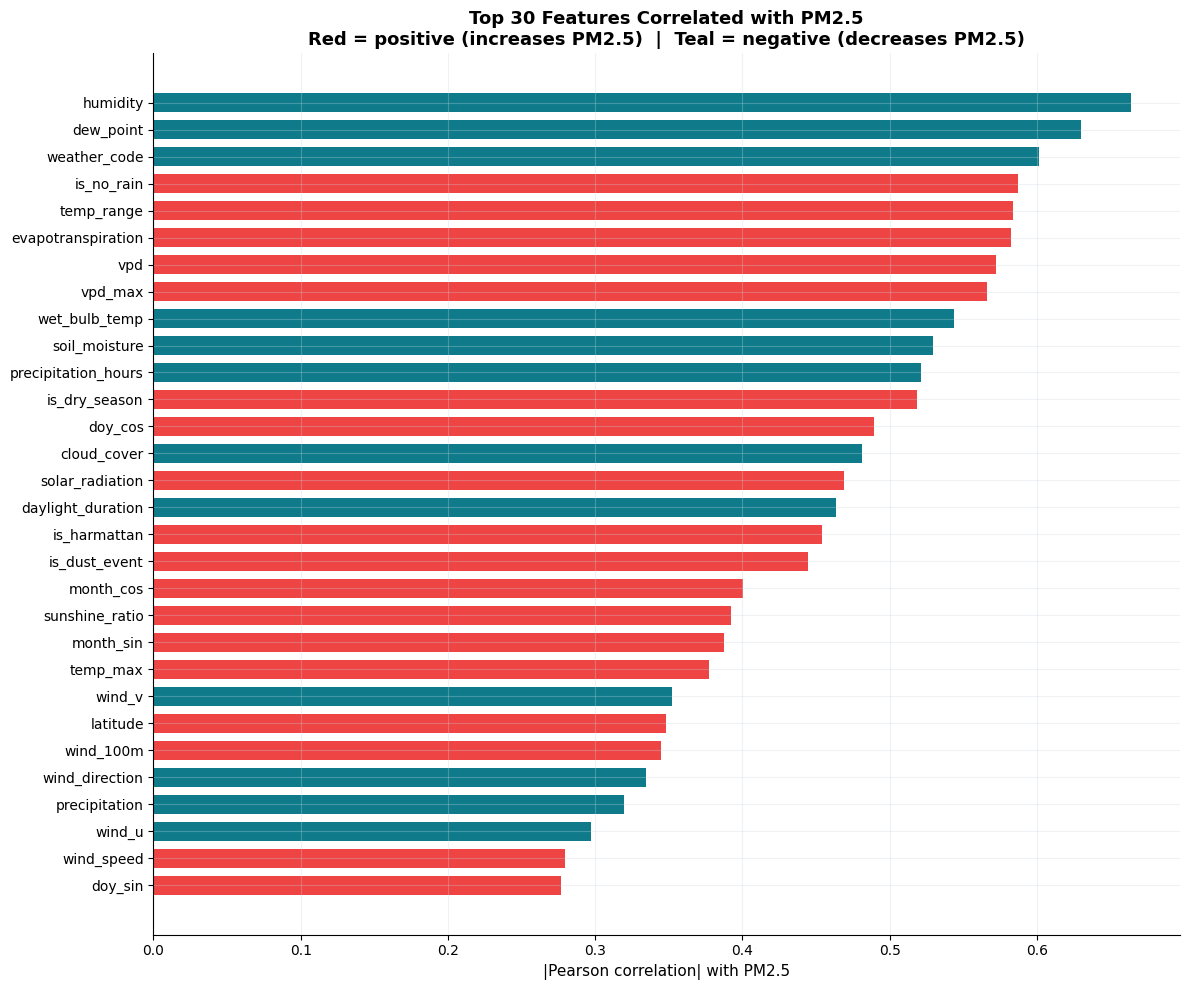


Top 15 features by absolute correlation with PM2.5:
  humidity                     r = -0.664
  dew_point                    r = -0.630
  weather_code                 r = -0.601
  is_no_rain                   r = +0.587
  temp_range                   r = +0.584
  evapotranspiration           r = +0.582
  vpd                          r = +0.572
  vpd_max                      r = +0.566
  wet_bulb_temp                r = -0.543
  soil_moisture                r = -0.529
  precipitation_hours          r = -0.522
  is_dry_season                r = +0.519
  doy_cos                      r = +0.489
  cloud_cover                  r = -0.481
  solar_radiation              r = +0.469


In [24]:
# ── Full feature correlation with PM2.5 target ───────────────────────────────
exclude = [
    # identifiers
    'date', 'city', 'region',
    # the target itself and its alias
    'pm2_5_target', 'pm25_target', 'pm2_5',
    # all other compound targets and raw columns
    'pm10', 'dust', 'co', 'no2', 'o3', 'so2', 'aod', 'eu_aqi',
    'pm10_target', 'dust_target', 'co_target', 'no2_target',
    'o3_target', 'so2_target', 'aod_target',
    # is_real flags — all 1s, no information
    'pm25_is_real', 'pm10_is_real', 'dust_is_real', 'co_is_real',
    'no2_is_real', 'so2_is_real', 'o3_is_real', 'aod_is_real',
    # proxy comparison column
    'pm25_starter_proxy',
    # engineered ratio
    'pm_ratio',
]

feature_cols = [c for c in df.columns
                if c not in exclude
                and df[c].dtype in ['float64','int64','int32']]

print(f"Features included : {len(feature_cols)}")
print(f"Excluded          : {len([c for c in df.columns if c in exclude])}")

corr_pm25 = df[feature_cols + ['pm25_target']].corr()['pm25_target'].drop('pm25_target')
corr_abs  = corr_pm25.abs().sort_values(ascending=False)

# ── Check weather_code before plotting ───────────────────────────────────────
print(f"\nweather_code correlation with PM2.5: r = {corr_pm25['weather_code']:.3f}")
print("\nMean PM2.5 by weather code:")
print(df.groupby('weather_code')['pm25_target']
      .agg(['mean','count'])
      .sort_values('mean', ascending=False)
      .round(1).to_string())

# ── Plot top 30 ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
top_n = 30
top_features = corr_abs.head(top_n)
colors = [RED if corr_pm25[f] > 0 else TEAL for f in top_features.index]
ax.barh(range(top_n), top_features.values[::-1],
        color=colors[::-1], edgecolor='none', height=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features.index[::-1], fontsize=10)
ax.set_xlabel('|Pearson correlation| with PM2.5')
ax.set_title(f'Top {top_n} Features Correlated with PM2.5\n'
             'Red = positive (increases PM2.5)  |  Teal = negative (decreases PM2.5)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(data_dir,'..','outputs','eda_15_feature_importance_preview.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 15 features by absolute correlation with PM2.5:')
for feat, val in corr_abs.head(15).items():
    direction = '+' if corr_pm25[feat] > 0 else '-'
    print(f'  {feat:<28} r = {direction}{val:.3f}')

In [25]:
# ── EDA summary ──────────────────────────────────────────────────────────────
print('='*65)
print('EDA COMPLETE — KEY FINDINGS')
print('='*65)

findings = [
    ('Mission Goal 1', 'PM2.5 distribution is right-skewed — log-transform may improve model performance'),
    ('Mission Goal 1', f'Overall {(df["pm25_target"]>15).mean()*100:.0f}% of city-days exceed WHO 24h limit (15 μg/m³)'),
    ('Mission Goal 2', 'Three distinct zones: Sahel North (dust-driven), Urban Centres (traffic), Southern Forest (clean)'),
    ('Mission Goal 2', 'Harmattan season in Far North raises PM2.5 by 2-3× vs non-Harmattan period'),
    ('Mission Goal 2', 'PM10/PM2.5 ratio fingerprints pollution source — high ratio = Saharan dust'),
    ('Mission Goal 2', 'NO₂ is highest in Douala and Yaoundé — confirms urban traffic as source'),
    ('Mission Goal 2', 'is_harmattan and wind_v are among the top correlated features — validates proxy formulas'),
    ('Mission Goal 3', f'Most polluted city: {city_pm25.index[0][0]} ({city_pm25.iloc[0]:.1f} μg/m³)'),
    ('Mission Goal 3', f'Cleanest city: {city_pm25.index[-1][0]} ({city_pm25.iloc[-1]:.1f} μg/m³)'),
    ('Mission Goal 3', 'Seasonal heatmap confirms red band Nov-Feb in northern regions — usable for calendar alerts'),
]

current_goal = ''
for goal, finding in findings:
    if goal != current_goal:
        print(f'\n  [{goal}]')
        current_goal = goal
    print(f'    • {finding}')

print(f'\n  Charts saved to: ../outputs/ (eda_01 through eda_15)')
print(f'  Ready for: Model Training')


EDA COMPLETE — KEY FINDINGS

  [Mission Goal 1]
    • PM2.5 distribution is right-skewed — log-transform may improve model performance
    • Overall 50% of city-days exceed WHO 24h limit (15 μg/m³)

  [Mission Goal 2]
    • Three distinct zones: Sahel North (dust-driven), Urban Centres (traffic), Southern Forest (clean)
    • Harmattan season in Far North raises PM2.5 by 2-3× vs non-Harmattan period
    • PM10/PM2.5 ratio fingerprints pollution source — high ratio = Saharan dust
    • NO₂ is highest in Douala and Yaoundé — confirms urban traffic as source
    • is_harmattan and wind_v are among the top correlated features — validates proxy formulas

  [Mission Goal 3]
    • Most polluted city: Kousseri (31.2 μg/m³)
    • Cleanest city: Kribi (8.7 μg/m³)
    • Seasonal heatmap confirms red band Nov-Feb in northern regions — usable for calendar alerts

  Charts saved to: ../outputs/ (eda_01 through eda_15)
  Ready for: Model Training


In [26]:
import pandas as pd, os

data_dir = os.path.abspath(os.path.join(os.getcwd(),'..','data'))
df = pd.read_csv(os.path.join(data_dir,'cameroon_final.csv'), parse_dates=['date'])

compounds = ['pm2_5','pm10','dust','co','no2','o3','so2','aod']

print("NULL CHECK IN SAVED FILE")
print("="*50)
for col in compounds:
    nulls = df[col].isnull().sum()
    pct   = nulls/len(df)*100
    print(f"  {col:<10} {nulls:>8,} nulls  ({pct:.1f}%)")

print(f"\nDate range of nulls:")
null_rows = df[df['pm2_5'].isnull()]
if len(null_rows) > 0:
    print(f"  {null_rows['date'].min().date()} to {null_rows['date'].max().date()}")
    print(f"  {len(null_rows):,} rows  ({len(null_rows)/len(df)*100:.1f}%)")
    print(f"  Cities affected: {null_rows['city'].nunique()}")
else:
    print("  No nulls in pm2_5")

NULL CHECK IN SAVED FILE
  pm2_5             0 nulls  (0.0%)
  pm10              0 nulls  (0.0%)
  dust              0 nulls  (0.0%)
  co                0 nulls  (0.0%)
  no2               0 nulls  (0.0%)
  o3                0 nulls  (0.0%)
  so2               0 nulls  (0.0%)
  aod               0 nulls  (0.0%)

Date range of nulls:
  No nulls in pm2_5
